# MITGCM Transect Stratification Analysis

**Purpose**: Code for quantifying the surface intensification of stratification  

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import os
import cmocean.cm as cmo
from geopy.distance import geodesic
import matplotlib.gridspec as gridspec

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_freq_marker, add_longitude_axis
from ocean_analysis import moderossby

Set plotting parameters

In [3]:
# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_mld = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_spec = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_grad = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load in mix layer depth and decorrelation scales along the transect

In [4]:
#-------------------------------------------------------#
# Mixed Layer depth Data
#-------------------------------------------------------#
filename_mld  = PATH + "/mitgcm_transect_mld_climatology.npz"

# Load data 
ds_mld   = np.load(filename_mld, allow_pickle=True)

# Extract data variables
mld                  = ds_mld['mld']                 # Units: meters
mld_monthly_mean     = ds_mld['mld_monthly_mean']    # Units: meters
mld_monthly_var      = ds_mld['mld_monthly_var']     # Units: meters
mld_monthly_stdm     = ds_mld['mld_monthly_stdm'] 
mld_monthly_stdv     = ds_mld['mld_monthly_stdv'] 
lat                  = ds_mld['lat'] 
lon                  = ds_mld['lon'] 
time_mld             = ds_mld['time']
time_mld_monthly     = ds_mld['time_monthly']

#-------------------------------------------------------#
# Decorrelation scale Data
#-------------------------------------------------------#
filename_decor  = PATH + "/mitgcm_transect_temporal_scale_densityCalCOFI_line80_unc.npz"

# Load data 
ds_decor   = np.load(filename_decor, allow_pickle=True)

# Extract data variables
Lt_days       = ds_decor['Lt_days']         # Units: days
Lt_stdm_days  = ds_decor['Lt_stdm_days']    # Units: days
dist          = ds_decor['dist']            # Units: kilometers
depth         = ds_decor['depth']

#-------------------------------------------------------#
# Spectral Analysis Data
#-------------------------------------------------------#
filename_spec = PATH_spec + "/mitgcm_transect_potential_density_spectra.npz"

# Load data 
ds_spec   = np.load(filename_spec, allow_pickle=True)

# Extract data variables
FVE           = ds_spec['FVE']         
FVE_stdm      = ds_spec['FVE_unc'] 

#-------------------------------------------------------#
# Kinetic Energy Analysis Data
#-------------------------------------------------------#
filename_ke_tot = PATH_grad + "/mitgcm_transect_ke.npz"
filename_ke_bc = PATH_grad + "/mitgcm_transect_ke_baroclinic.npz"

# Load data 
ds_ke_tot   = np.load(filename_ke_tot, allow_pickle=True)
ds_ke_bc   = np.load(filename_ke_bc, allow_pickle=True)

# Extract data variables
FKE_tot       = ds_ke_tot['FKE']
FKE_bc        = ds_ke_bc['FKE']

#-------------------------------------------------------#
# Spatial Gradient Analysis Data
#-------------------------------------------------------#
filename_grad = PATH_grad + "/mitgcm_transect_spatial_gradients.npz"

# Load data 
ds_grad   = np.load(filename_grad, allow_pickle=True)

# Extract data variables
u_along_bar_mean       = ds_grad['u_along_bar_mean']
u_cross_bar_mean       = ds_grad['u_cross_bar_mean']
u_along_mean           = ds_grad['u_along_mean']
u_cross_mean           = ds_grad['u_cross_mean']
drho_dx_mean           = ds_grad['drho_dx_mean']      

#-------------------------------------------------------#
# Stratification Data
#-------------------------------------------------------#
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
nc_tsd = Dataset(filename_tsd, 'r')

# Extract data variables
depth_mid = nc_tsd.variables['depth_mid'][:]
dist_nz      = nc_tsd.variables['DIST'][:]    
Nz  = nc_tsd.variables['NZ'][:] 

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
Nz = Nz[::-1,:]

#-------------------------------------------------------#
# Ocean Bottom Data
#-------------------------------------------------------#

# Set filename and read in netcdf file
filename = PATH_mld + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Mask fill values

In [5]:
u_along_mean = np.ma.masked_where(u_along_mean == 0, u_along_mean)
u_cross_mean = np.ma.masked_where(u_cross_mean == 0, u_cross_mean)
FKE_tot = np.ma.masked_where(FKE_tot == 0, FKE_tot)

Slice the data so that the analysis only considers offshore distances up to 123 degrees west

In [6]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat          = lat[idx_dist]
lon          = lon[idx_dist]
bottom_depth = bottom_depth[idx_dist]
mld          = mld[idx_dist,:]
mld_monthly_mean = mld_monthly_mean[idx_dist,:]
Nz           = Nz[idx_dist,:]
dist_nz      = dist_nz[idx_dist]

Compute cumulative distance along line 80.0 the mixed layer depth 

In [7]:
# Initialize array 
dist_mld = np.zeros(len(lon))

# Loop through stations 
for i in range(1,len(lon)): 

    # Define i and i + 1 points along transect
    pt1 = (lat[i-1], lon[i-1])
    pt2 = (lat[i],   lon[i])

    # Compute distance in kilometers along transect
    dist_mld[i] = dist_mld[i-1] + geodesic(pt1, pt2).km

Set the locations of each cce mooring

In [8]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53816
lat3 = 34.448512

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Compute the distance from the final CalCOFI station (closest to shore) and the shore

In [9]:
# Define points 
calcofi_station = (lat[0], lon[0])
shore           = (lat_shore,   lon_shore)

# Compute distance
dist_offset = geodesic(calcofi_station, shore).km

# Apply distance from shore correction
dist_cor     = dist + dist_offset
dist_mld_cor = dist_mld + dist_offset

Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [10]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_rho_spatial_mean = np.mean(Lt_days) 

# Compute the relative uncertainty
Lt_rho_rel_unc = Lt_stdm_days / (Lt_days - Lt_rho_spatial_mean)

# Mask not statistically significant grid points
Lt_rho_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rho_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
rho_mask = np.where(Lt_rho_mask, 1, np.nan)

Compute the seasonally averaged mixed layer depth 

In [11]:
mld_mean = np.mean(mld_monthly_mean,axis=1)
mld_std  = np.std(mld_monthly_mean,ddof=1,axis=1)

### **Step 1**: Quantifying the surface-intensification of stratification approaching the coast 

In [12]:
# Compute positive downward depth 
z_pos = np.abs(depth_mid)

# Obtain dimensions of data 
n_dist, n_depth = len(dist_nz), len(depth_mid)
n_modes         = 5
n_depth_interp  = 1025

# Initialize arrays
z_centroid = np.full(n_dist, np.nan)
z_max = np.full(n_dist, np.nan)
Rd_barotropic = np.full((n_dist), np.nan)
Rd_baroclinic = np.full((n_dist, n_modes), np.nan)
psi_baroclinic = np.full((n_dist, n_depth_interp, n_modes), np.nan)

# Loop over offshore distance
for idist in range(n_dist):

    # Set progress bar
    progress = (idist + 1) / (n_dist-1)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Obtain N profile for ith distance and convert to units 1/s
    profile = Nz[idist, :]/3600

    # Remove NaNs / masked values
    mask = np.isfinite(profile) & np.isfinite(z_pos)

    # Skip profiles with insufficient valid data
    if np.sum(mask) < 2:
        continue
    
    # Extract valid N^2 values and corresponding depths
    z_valid = z_pos[mask]
    profile_valid = profile[mask]

    # Skip if all values are zero or masked
    if profile_valid.size == 0:
        continue

    # Compute N^2 profile for ith distance
    profile_valid_squared = profile_valid**2

    # ---------------------------------------------------------------------
    # Compute Stratification centroid
    #
    # z_c = integral(z*N^2 dz) / integral(N^2 dz)
    # ---------------------------------------------------------------------
    numerator = np.trapezoid(z_valid * profile_valid_squared, z_valid)
    denominator = np.trapezoid(profile_valid_squared, z_valid)

    if denominator > 0:
        z_centroid[idist] = numerator / denominator

    # ---------------------------------------------------------------------
    # Compute the depth of maximum stratification
    # ---------------------------------------------------------------------
    idx_max = np.nanargmax(profile_valid_squared)

    z_max[idist] = z_valid[idx_max]

    # ---------------------------------------------------------------------
    # Compute the first baroclinic Rossby radius of deformation
    # ---------------------------------------------------------------------

    # Solve the eigenvalue problem to compute eigenvalues of the vertical structure equation
    lambda1sq, psi_baroclinic[idist,:,:], z_interp, lambda0sq, _ = moderossby(z_valid, profile_valid, lat[idist], nmodes=n_modes)

    # Convert eigenvalues to Rossby radii of deformation
    Rd_barotropic[idist] = (1.0 / np.sqrt(np.abs(lambda0sq)))/1000  # Barotropic deformation radius (units: km)
    Rd_baroclinic[idist,:] = (1.0 / np.sqrt(np.abs(lambda1sq)))/1000  # Baroclinic deformation radius (units: km)

# Compute the normalized stratification centroid and depth of maximum stratification by water depth 
z_centroid_norm = z_centroid / np.abs(bottom_depth)
z_max_norm = z_max / np.abs(bottom_depth)

Progress: 1.5%

Progress: 100.7%

Compute the depth averaged decorrelation time scale for the upper 15 meters

In [13]:
# Set the depth threshold and positive downward depth array
z_o   = 15             # Depth threshold (units: meters)
z_pos = np.abs(depth)  # Positive downward depth array

# Find indices for depths shallower than z_o 
idx_depth = np.where(z_pos <= z_o)[0]

# Compute depth steps for weighted mean calculation
dz = np.gradient(z_pos)

# Compute weighted mean of decorrelation time scale for depths shallower than z_o 
Lt_days_mean = np.average(Lt_days[:,idx_depth], weights=dz[idx_depth], axis = 1)

Mask zeros in Lt_days_mean 

In [14]:
Lt_days_mean = np.ma.masked_where(Lt_days_mean == 0, Lt_days_mean)

### **Step 2**: Plot the stratification centroid and maximum depth as a function of distance from shore

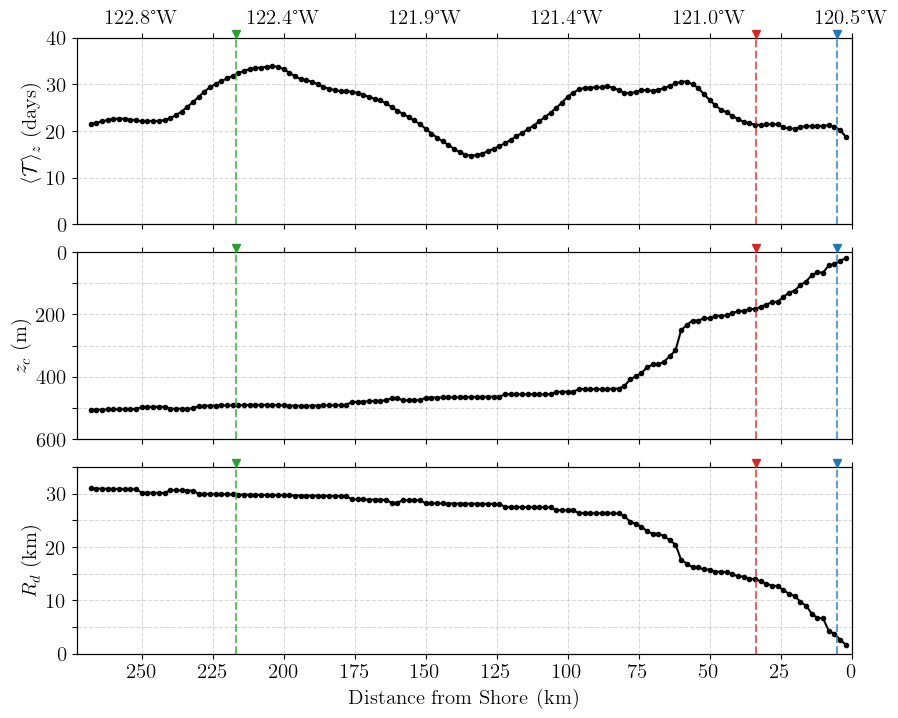

In [22]:
# Set plotting parameters
lon_markers = [lon1, lon2, lon3]
colors = ['tab:green', 'tab:red', 'tab:blue']

# Create figure
fig, axes = plt.subplots(3,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot depth-averaged decorrelation time scale 
ax.plot(dist, Lt_days_mean, color='k', lw = 1.5, linestyle='-', marker='.')

# Set axis attributes
ax.set_ylabel(r'$\langle \mathcal{T} \rangle_z$ (days)')
ax.set_xlim(0,dist[-1]+5)
ax.set_ylim(0,40)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set top axis for longitude
ax_top, marker_distances = add_longitude_axis(
    ax,
    dist,
    lon,
    lon_markers=lon_markers,
    marker_colors=colors,
    marker_func=add_freq_marker,
    marker_kwargs=dict(
        y_marker=1.02,
        y_text=1.035,
        fontsize=14
    )
)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Plot the stratification centroid normalized by water depth
ax.plot(dist, z_centroid, '.-', lw = 1.5, color = 'k')

# Set axis attributes
ax.set_ylabel(r'$z_{c}$ (m)')
ax.set_xlim(0,dist[-1]+5)
ax.set_ylim(0,600)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,600+100,100))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Show every other label
yticks = np.arange(0,600+100,100)
ax.set_yticklabels([
    f"{y:g}" if i % 2 == 0 else ""
    for i, y in enumerate(yticks)
])

# Set top axis for longitude
ax_top, marker_distances = add_longitude_axis(
    ax,
    dist,
    lon,
    lon_markers=lon_markers,
    marker_colors=colors,
    marker_func=add_freq_marker,
    marker_kwargs=dict(
        y_marker=1.02,
        y_text=1.035,
        fontsize=14
    )
)

# Remove top and bottom x-axis ticklabels
ax_top.set_xticklabels([])
ax.set_xticklabels([])

#--- Subplot 3 ---# 
ax = axes[2]

# Plot the first baroclinic Rossby radius of deformation
ax.plot(dist, Rd_baroclinic[:,0], color='k', lw = 1.5, linestyle='-', marker='.')

# Set axis attributes
ax.set_xlabel(r'Distance from Shore (km)')
ax.set_ylabel(r'$R_d$ (km)')
ax.set_xlim(0,dist[-1]+5)
ax.set_ylim(0,35)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,35+5,5))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Show every other label
yticks = np.arange(0, 35 + 5, 5)
ax.set_yticklabels([
    f"{y:g}" if i % 2 == 0 else ""
    for i, y in enumerate(yticks)
])

# Set top axis for longitude
ax_top, marker_distances = add_longitude_axis(
    ax,
    dist,
    lon,
    lon_markers=lon_markers,
    marker_colors=colors,
    marker_func=add_freq_marker,
    marker_kwargs=dict(
        y_marker=1.02,
        y_text=1.035,
        fontsize=14
    )
)

# Remove top and bottom x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.15, wspace=0.1)
plt.show()

# Save with high quality
# figName = 'figS08.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Plot Mode 1 and 2 vertical structure functions

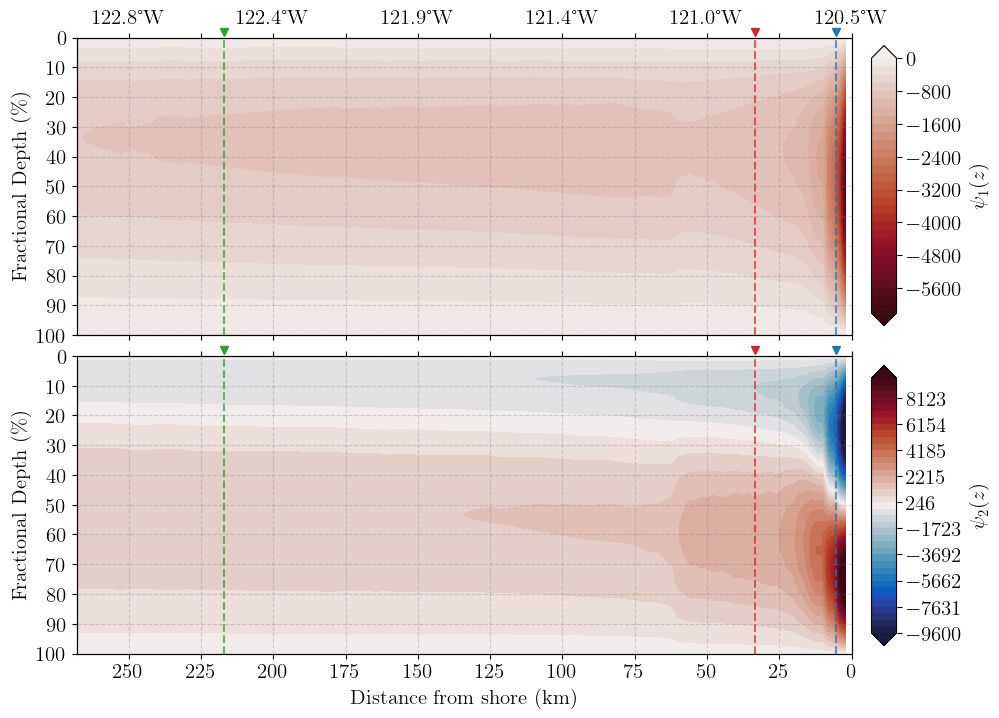

In [18]:
# Set plotting parameters
cmap = cmo.amp
fractional_depth = 100*(np.arange(0,len(z_interp)) / len(z_interp))

# Create figure
fig, axes = plt.subplots(2,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot the first baroclinic mode of the baroclinic structure function
cf = ax.contourf(dist_nz,fractional_depth,psi_baroclinic[:,:,0].T, levels=40, cmap=cmo.amp_r, extend='both')

# Plot the ocean bottom depth 
#ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel(r'Fractional Depth (\%)')
ax.set_ylim(0,100)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,100+10,10))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.52, 0.025, 0.35])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'$\psi_1(z)$')

# Set top axis for longitude
ax_top, marker_distances = add_longitude_axis(
    ax,
    dist,
    lon,
    lon_markers=lon_markers,
    marker_colors=colors,
    marker_func=add_freq_marker,
    marker_kwargs=dict(
        y_marker=1.02,
        y_text=1.035,
        fontsize=14
    )
)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Plot the first baroclinic mode of the baroclinic structure function
cf = ax.contourf(dist_nz,fractional_depth,psi_baroclinic[:,:,1].T, levels=np.linspace(-9600,9600,40), cmap=cmo.balance, extend='both')

# Plot the ocean bottom depth 
#ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Fractional Depth (\%)')
ax.set_ylim(0,100)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,100+10,10))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.12, 0.025, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'$\psi_2(z)$')

# Set top axis for longitude
ax_top, marker_distances = add_longitude_axis(
    ax,
    dist,
    lon,
    lon_markers=lon_markers,
    marker_colors=colors,
    marker_func=add_freq_marker,
    marker_kwargs=dict(
        y_marker=1.02,
        y_text=1.035,
        fontsize=14
    )
)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
# figName = 'figS08.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )
